In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

In [16]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64

torch.manual_seed(1234)

print("device:", device)
print("dtype:", dtype)

device: cuda
dtype: torch.float64


In [17]:
T = 1.0
omega = torch.tensor(1.0, device=device, dtype=dtype)

dim = 1

mu_0 = torch.tensor([0.0], device=device, dtype=dtype)
mu_T = torch.tensor([1.0], device=device, dtype=dtype)

sigma_0 = torch.tensor([0.2], device=device, dtype=dtype)
sigma_T = torch.tensor([0.2], device=device, dtype=dtype)

K = 8
n_steps_per_segment = 16

In [11]:
def exact_solution(t):
    """
    Exact solution for:

        mu'' = -omega^2 mu
        sigma'' = 0

    with boundary values at t = 0 and t = T.

    Input:
        t: Tensor[n]

    Returns:
        mu, sigma, dmu, dsigma
        each with shape [n, dim]
    """

    t = t.to(device=device, dtype=dtype)
    t_col = t.reshape(-1, 1)

    omega_T = torch.tensor(omega * T, device=device, dtype=dtype)
    denom = torch.sin(omega_T)

    if torch.abs(denom) < 1e-10:
        raise ValueError("The BVP is close to a conjugate time: sin(omega*T) ≈ 0.")

    b = (mu_T - mu_0 * torch.cos(omega_T)) / denom

    mu = (
        mu_0 * torch.cos(omega * t_col)
        + b * torch.sin(omega * t_col)
    )

    dmu = (
        -omega * mu_0 * torch.sin(omega * t_col)
        + omega * b * torch.cos(omega * t_col)
    )

    sigma = sigma_0 + (sigma_T - sigma_0) * (t_col / T)
    dsigma = (sigma_T - sigma_0) / T
    dsigma = dsigma.expand_as(sigma)

    return mu, sigma, dmu, dsigma

In [18]:
def initialize_straight_path(mu_0, sigma_0, mu_T, sigma_T, K):
    t_nodes = torch.linspace(
        0.0,
        T,
        K + 1,
        device=mu_0.device,
        dtype=mu_0.dtype,
    )

    alphas = (t_nodes / T).reshape(-1, 1)

    mu_nodes = (1.0 - alphas) * mu_0 + alphas * mu_T
    sigma_nodes = (1.0 - alphas) * sigma_0 + alphas * sigma_T

    dmu_const = (mu_T - mu_0) / T
    dsigma_const = (sigma_T - sigma_0) / T

    dmu_nodes = dmu_const.expand_as(mu_nodes).clone()
    dsigma_nodes = dsigma_const.expand_as(sigma_nodes).clone()

    mu_nodes[0] = mu_0
    mu_nodes[-1] = mu_T

    sigma_nodes[0] = sigma_0
    sigma_nodes[-1] = sigma_T

    return t_nodes, mu_nodes, sigma_nodes, dmu_nodes, dsigma_nodes


t_nodes, mu_init_nodes, sigma_init_nodes, dmu_init_nodes, dsigma_init_nodes = (
    initialize_straight_path(mu_0, sigma_0, mu_T, sigma_T, K)
)

In [19]:
def leapfrog_segment(
    mu,
    sigma,
    dmu,
    dsigma,
    t0,
    t1,
    n_steps,
    omega,
):
    h = (t1 - t0) / n_steps

    mu_path = [mu]
    sigma_path = [sigma]
    dmu_path = [dmu]
    dsigma_path = [dsigma]

    omega_sq = omega * omega

    for _ in range(n_steps):
        dmu_half = dmu - 0.5 * h * omega_sq * mu
        dsigma_half = dsigma

        mu_new = mu + h * dmu_half
        sigma_new = sigma + h * dsigma_half

        dmu_new = dmu_half - 0.5 * h * omega_sq * mu_new
        dsigma_new = dsigma_half

        mu, sigma, dmu, dsigma = mu_new, sigma_new, dmu_new, dsigma_new

        mu_path.append(mu)
        sigma_path.append(sigma)
        dmu_path.append(dmu)
        dsigma_path.append(dsigma)

    return {
        "mu_path": torch.stack(mu_path, dim=0),
        "sigma_path": torch.stack(sigma_path, dim=0),
        "dmu_path": torch.stack(dmu_path, dim=0),
        "dsigma_path": torch.stack(dsigma_path, dim=0),
        "mu_final": mu,
        "sigma_final": sigma,
        "dmu_final": dmu,
        "dsigma_final": dsigma,
    }

In [27]:
def inverse_softplus(x, eps=1e-12):
    x = torch.clamp(x, min=eps)
    return torch.log(torch.expm1(x))


class HarmonicMultipleShooting(nn.Module):
    def __init__(
        self,
        mu_init_nodes,
        sigma_init_nodes,
        dmu_init_nodes,
        dsigma_init_nodes,
        sigma_min=1e-8,
    ):
        super().__init__()

        assert mu_init_nodes.ndim == 2
        assert sigma_init_nodes.ndim == 2
        assert dmu_init_nodes.ndim == 2
        assert dsigma_init_nodes.ndim == 2

        assert mu_init_nodes.shape == sigma_init_nodes.shape
        assert mu_init_nodes.shape == dmu_init_nodes.shape
        assert mu_init_nodes.shape == dsigma_init_nodes.shape

        self.K = mu_init_nodes.shape[0] - 1
        self.sigma_min = sigma_min

        # Fixed endpoint positions.
        self.register_buffer("mu_0", mu_init_nodes[0].clone())
        self.register_buffer("mu_T", mu_init_nodes[-1].clone())

        self.register_buffer("sigma_0", sigma_init_nodes[0].clone())
        self.register_buffer("sigma_T", sigma_init_nodes[-1].clone())

        # Trainable interior positions.
        if self.K > 1:
            self.mu_mid = nn.Parameter(mu_init_nodes[1:-1].clone())

            raw_sigma_mid = inverse_softplus(
                sigma_init_nodes[1:-1] - sigma_min
            )
            self.raw_sigma_mid = nn.Parameter(raw_sigma_mid)
        else:
            self.mu_mid = None
            self.raw_sigma_mid = None

        # Trainable velocities at all nodes, including endpoints.
        self.dmu_nodes = nn.Parameter(dmu_init_nodes.clone())
        self.dsigma_nodes = nn.Parameter(dsigma_init_nodes.clone())

    def get_nodes(self):
        mu_0 = self.mu_0.unsqueeze(0)
        mu_T = self.mu_T.unsqueeze(0)

        sigma_0 = self.sigma_0.unsqueeze(0)
        sigma_T = self.sigma_T.unsqueeze(0)

        if self.K == 1:
            mu_nodes = torch.cat([mu_0, mu_T], dim=0)
            sigma_nodes = torch.cat([sigma_0, sigma_T], dim=0)
        else:
            sigma_mid = self.sigma_min + F.softplus(self.raw_sigma_mid)

            mu_nodes = torch.cat(
                [mu_0, self.mu_mid, mu_T],
                dim=0,
            )

            sigma_nodes = torch.cat(
                [sigma_0, sigma_mid, sigma_T],
                dim=0,
            )

        return mu_nodes, sigma_nodes, self.dmu_nodes, self.dsigma_nodes

    def forward(
        self,
        t_nodes,
        omega,
        n_steps_per_segment,
        lambda_position=1.0,
        lambda_velocity=1.0,
        lambda_node_regularization=0.0,
        return_segments=False,
    ):
        mu_nodes, sigma_nodes, dmu_nodes, dsigma_nodes = self.get_nodes()

        position_defect = torch.zeros((), device=mu_nodes.device, dtype=mu_nodes.dtype)
        velocity_defect = torch.zeros((), device=mu_nodes.device, dtype=mu_nodes.dtype)
        node_reg = torch.zeros((), device=mu_nodes.device, dtype=mu_nodes.dtype)

        segments = []

        for k in range(self.K):
            seg = leapfrog_segment(
                mu=mu_nodes[k],
                sigma=sigma_nodes[k],
                dmu=dmu_nodes[k],
                dsigma=dsigma_nodes[k],
                t0=t_nodes[k],
                t1=t_nodes[k + 1],
                n_steps=n_steps_per_segment,
                omega=omega,
            )

            mu_hat = seg["mu_final"]
            sigma_hat = seg["sigma_final"]
            dmu_hat = seg["dmu_final"]
            dsigma_hat = seg["dsigma_final"]

            mu_next = mu_nodes[k + 1]
            sigma_next = sigma_nodes[k + 1]
            dmu_next = dmu_nodes[k + 1]
            dsigma_next = dsigma_nodes[k + 1]

            position_defect = position_defect + (
                (mu_hat - mu_next).pow(2).mean()
                + (sigma_hat - sigma_next).pow(2).mean()
            )

            velocity_defect = velocity_defect + (
                (dmu_hat - dmu_next).pow(2).mean()
                + (dsigma_hat - dsigma_next).pow(2).mean()
            )

            if return_segments:
                segments.append(seg)

        if lambda_node_regularization > 0.0 and self.K >= 2:
            d2_mu = mu_nodes[:-2] - 2.0 * mu_nodes[1:-1] + mu_nodes[2:]
            d2_sigma = sigma_nodes[:-2] - 2.0 * sigma_nodes[1:-1] + sigma_nodes[2:]
            d2_dmu = dmu_nodes[:-2] - 2.0 * dmu_nodes[1:-1] + dmu_nodes[2:]
            d2_dsigma = dsigma_nodes[:-2] - 2.0 * dsigma_nodes[1:-1] + dsigma_nodes[2:]

            node_reg = (
                d2_mu.pow(2).mean()
                + d2_sigma.pow(2).mean()
                + d2_dmu.pow(2).mean()
                + d2_dsigma.pow(2).mean()
            )

        loss = (
            lambda_position * position_defect
            + lambda_velocity * velocity_defect
            + lambda_node_regularization * node_reg
        )

        diagnostics = {
            "loss": loss.detach(),
            "position_defect": position_defect.detach(),
            "velocity_defect": velocity_defect.detach(),
            "node_reg": node_reg.detach(),
            "mu_nodes": mu_nodes.detach(),
            "sigma_nodes": sigma_nodes.detach(),
            "dmu_nodes": dmu_nodes.detach(),
            "dsigma_nodes": dsigma_nodes.detach(),
        }

        if return_segments:
            diagnostics["segments"] = segments

        return loss, diagnostics

In [28]:
model = HarmonicMultipleShooting(
    mu_init_nodes=mu_init_nodes,
    sigma_init_nodes=sigma_init_nodes,
    dmu_init_nodes=dmu_init_nodes,
    dsigma_init_nodes=dsigma_init_nodes,
).to(device=device, dtype=dtype)

# Important: create optimizer after model.to(...)
# foreach=False avoids this common PyTorch dtype/device bug.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-2,
    foreach=False,
)

In [29]:
def check_model_devices(model):
    print("Parameters:")
    for name, p in model.named_parameters():
        print(name, p.device, p.dtype, p.requires_grad)

    print("\nBuffers:")
    for name, b in model.named_buffers():
        print(name, b.device, b.dtype)


check_model_devices(model)

print("t_nodes:", t_nodes.device, t_nodes.dtype)
print("omega:", omega.device, omega.dtype)

Parameters:
mu_mid cuda:0 torch.float64 True
raw_sigma_mid cuda:0 torch.float64 True
dmu_nodes cuda:0 torch.float64 True
dsigma_nodes cuda:0 torch.float64 True

Buffers:
mu_0 cuda:0 torch.float64
mu_T cuda:0 torch.float64
sigma_0 cuda:0 torch.float64
sigma_T cuda:0 torch.float64
t_nodes: cuda:0 torch.float64
omega: cuda:0 torch.float64


In [30]:
n_iters = 5000

lambda_position = 1.0
lambda_velocity = 1.0
lambda_node_regularization = 0.0

history = []

for it in range(n_iters + 1):
    optimizer.zero_grad(set_to_none=True)

    loss, diagnostics = model(
        t_nodes=t_nodes,
        omega=omega,
        n_steps_per_segment=n_steps_per_segment,
        lambda_position=lambda_position,
        lambda_velocity=lambda_velocity,
        lambda_node_regularization=lambda_node_regularization,
        return_segments=False,
    )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=10.0,
        foreach=False,
    )

    optimizer.step()

    if loss.item() <= 10**-5:
        break

    record = {
        "loss": diagnostics["loss"].item(),
        "position_defect": diagnostics["position_defect"].item(),
        "velocity_defect": diagnostics["velocity_defect"].item(),
        "node_reg": diagnostics["node_reg"].item(),
    }

    history.append(record)

    if it % 500 == 0:
        print(
            f"it={it:05d} | "
            f"loss={record['loss']:.4e} | "
            f"pos={record['position_defect']:.4e} | "
            f"vel={record['velocity_defect']:.4e}"
        )

it=00000 | loss=4.1450e-02 | pos=1.5170e-04 | vel=4.1298e-02


In [31]:
@torch.no_grad()
def reconstruct_trajectory(model, t_nodes, omega, n_steps_per_segment):
    loss, diagnostics = model(
        t_nodes=t_nodes,
        omega=omega,
        n_steps_per_segment=n_steps_per_segment,
        lambda_position=lambda_position,
        lambda_velocity=lambda_velocity,
        lambda_node_regularization=lambda_node_regularization,
        return_segments=True,
    )

    segments = diagnostics["segments"]

    t_all = []
    mu_all = []
    sigma_all = []
    dmu_all = []
    dsigma_all = []

    for k, seg in enumerate(segments):
        t_seg = torch.linspace(
            t_nodes[k],
            t_nodes[k + 1],
            n_steps_per_segment + 1,
            device=device,
            dtype=dtype,
        )

        if k == 0:
            sl = slice(None)
        else:
            sl = slice(1, None)

        t_all.append(t_seg[sl])
        mu_all.append(seg["mu_path"][sl])
        sigma_all.append(seg["sigma_path"][sl])
        dmu_all.append(seg["dmu_path"][sl])
        dsigma_all.append(seg["dsigma_path"][sl])

    t_all = torch.cat(t_all, dim=0)
    mu_all = torch.cat(mu_all, dim=0)
    sigma_all = torch.cat(sigma_all, dim=0)
    dmu_all = torch.cat(dmu_all, dim=0)
    dsigma_all = torch.cat(dsigma_all, dim=0)

    return t_all, mu_all, sigma_all, dmu_all, dsigma_all, diagnostics


t_ms, mu_ms, sigma_ms, dmu_ms, dsigma_ms, diagnostics_ms = reconstruct_trajectory(
    model=model,
    t_nodes=t_nodes,
    omega=omega,
    n_steps_per_segment=n_steps_per_segment,
)

print("Final diagnostics:")
print("loss:", diagnostics_ms["loss"].item())
print("position defect:", diagnostics_ms["position_defect"].item())
print("velocity defect:", diagnostics_ms["velocity_defect"].item())

Final diagnostics:
loss: 9.23149849329025e-06
position defect: 8.492366908213889e-06
velocity defect: 7.391315850763612e-07


In [32]:
t_exact = torch.linspace(0.0, T, 500, device=device, dtype=dtype)
mu_exact, sigma_exact, dmu_exact, dsigma_exact = exact_solution(t_exact)

# Exact solution evaluated on the reconstructed MS time grid.
mu_exact_ms, sigma_exact_ms, dmu_exact_ms, dsigma_exact_ms = exact_solution(t_ms)

mu_err = torch.max(torch.abs(mu_ms - mu_exact_ms)).item()
sigma_err = torch.max(torch.abs(sigma_ms - sigma_exact_ms)).item()
dmu_err = torch.max(torch.abs(dmu_ms - dmu_exact_ms)).item()
dsigma_err = torch.max(torch.abs(dsigma_ms - dsigma_exact_ms)).item()

print(f"max |mu_ms - mu_exact|       = {mu_err:.4e}")
print(f"max |sigma_ms - sigma_exact| = {sigma_err:.4e}")
print(f"max |dmu_ms - dmu_exact|     = {dmu_err:.4e}")
print(f"max |dsigma_ms - dsigma_exact| = {dsigma_err:.4e}")

max |mu_ms - mu_exact|       = 9.4412e-04
max |sigma_ms - sigma_exact| = 0.0000e+00
max |dmu_ms - dmu_exact|     = 9.2476e-03
max |dsigma_ms - dsigma_exact| = 0.0000e+00


/tmp/ipykernel_1274990/998448361.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  omega_T = torch.tensor(omega * T, device=device, dtype=dtype)


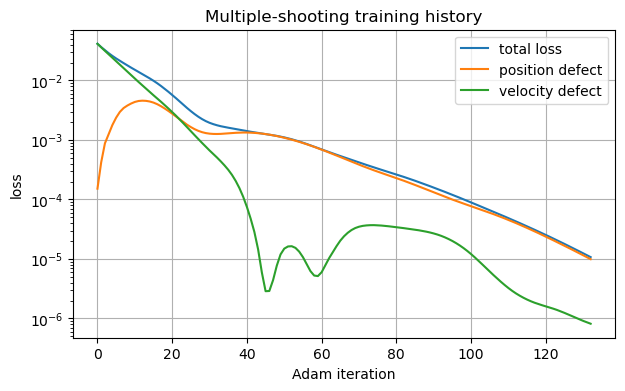

In [33]:
loss_values = [h["loss"] for h in history]
pos_values = [h["position_defect"] for h in history]
vel_values = [h["velocity_defect"] for h in history]

plt.figure(figsize=(7, 4))
plt.semilogy(loss_values, label="total loss")
plt.semilogy(pos_values, label="position defect")
plt.semilogy(vel_values, label="velocity defect")
plt.xlabel("Adam iteration")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.title("Multiple-shooting training history")
plt.show()

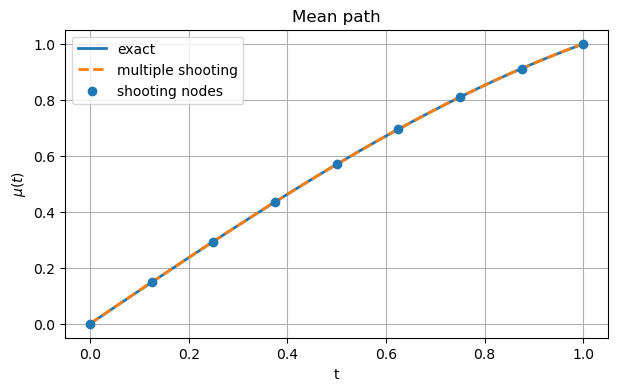

In [34]:
plt.figure(figsize=(7, 4))

plt.plot(
    t_exact.detach().cpu(),
    mu_exact.detach().cpu()[:, 0],
    label="exact",
    linewidth=2,
)

plt.plot(
    t_ms.detach().cpu(),
    mu_ms.detach().cpu()[:, 0],
    "--",
    label="multiple shooting",
    linewidth=2,
)

mu_nodes = diagnostics_ms["mu_nodes"]

plt.scatter(
    t_nodes.detach().cpu(),
    mu_nodes.detach().cpu()[:, 0],
    label="shooting nodes",
    zorder=3,
)

plt.xlabel("t")
plt.ylabel(r"$\mu(t)$")
plt.title("Mean path")
plt.legend()
plt.grid(True)
plt.show()

In [98]:
n_moving = 2
particle_dim = 2
dim = n_moving * particle_dim

# Co-orbital bridge geometry.
r = 1.0
alpha = math.pi / 2
square_width = 0.005
endpoint_std = square_width

fixed_position = torch.tensor(
    [0.0, 0.0],
    device=device,
    dtype=dtype,
)

source_positions = torch.tensor(
    [[-2.0 * r, 0.0], [-r, 0.0]],
    device=device,
    dtype=dtype,
)

rotation_matrix = torch.tensor(
    [
        [math.cos(alpha), -math.sin(alpha)],
        [math.sin(alpha),  math.cos(alpha)],
    ],
    device=device,
    dtype=dtype,
)

target_positions = source_positions @ rotation_matrix.T

source_mean = source_positions.reshape(-1)
target_mean = target_positions.reshape(-1)

source_sigma = endpoint_std * torch.ones_like(source_mean)
target_sigma = endpoint_std * torch.ones_like(target_mean)

print("source positions:")
print(source_positions)

print("target positions:")
print(target_positions)

print("source_mean:", source_mean)
print("target_mean:", target_mean)

source positions:
tensor([[-2.,  0.],
        [-1.,  0.]], device='cuda:0')
target positions:
tensor([[-1.2246e-16, -2.0000e+00],
        [-6.1232e-17, -1.0000e+00]], device='cuda:0')
source_mean: tensor([-2.,  0., -1.,  0.], device='cuda:0')
target_mean: tensor([-1.2246e-16, -2.0000e+00, -6.1232e-17, -1.0000e+00], device='cuda:0')


In [99]:
class FixedCenterThreeBodyPotential(nn.Module):
    def __init__(
        self,
        n_moving=2,
        particle_dim=2,
        fixed_position=None,
        G_center=0.10,
        G_pair=0.02,
        center_mass=1.0,
        softening=0.10,
        n_mc=64,
        include_sigma_force=False,
        seed=1234,
    ):
        super().__init__()

        self.n_moving = n_moving
        self.particle_dim = particle_dim
        self.dim = n_moving * particle_dim

        self.G_center = G_center
        self.G_pair = G_pair
        self.center_mass = center_mass
        self.softening = softening
        self.n_mc = n_mc
        self.include_sigma_force = include_sigma_force

        if fixed_position is None:
            fixed_position = torch.zeros(particle_dim, device=device, dtype=dtype)

        self.register_buffer("fixed_position", fixed_position.clone())

        # Fixed Monte Carlo samples for deterministic optimization.
        # Shape: [n_mc, dim]
        gen = torch.Generator(device="cpu")
        gen.manual_seed(seed)

        xi = torch.randn(n_mc, self.dim, generator=gen, dtype=dtype)
        xi = xi.to(device)

        # Antithetic samples reduce noise in sigma gradients.
        xi = torch.cat([xi, -xi], dim=0)

        self.register_buffer("xi", xi)

    def particle_potential(self, q_flat):
        """
        q_flat: Tensor[..., dim]

        Returns:
            U: Tensor[...]

        The last dimension stores:
            [x1, y1, x2, y2]
        """

        q = q_flat.reshape(*q_flat.shape[:-1], self.n_moving, self.particle_dim)

        # Attraction to fixed center.
        diff_center = q - self.fixed_position
        r_center_sq = diff_center.pow(2).sum(dim=-1) + self.softening**2
        r_center = torch.sqrt(r_center_sq)

        U_center = -self.G_center * self.center_mass * (1.0 / r_center).sum(dim=-1)

        # Pairwise moving-particle attraction.
        q1 = q[..., 0, :]
        q2 = q[..., 1, :]

        diff_pair = q1 - q2
        r_pair_sq = diff_pair.pow(2).sum(dim=-1) + self.softening**2
        r_pair = torch.sqrt(r_pair_sq)

        U_pair = -self.G_pair * (1.0 / r_pair)

        return U_center + U_pair

    def expected_potential(self, mu, sigma):
        """
        Monte Carlo approximation of E[U(mu + sigma * Z)].

        mu:    Tensor[dim]
        sigma: Tensor[dim]

        Returns:
            scalar tensor
        """

        q_samples = mu.unsqueeze(0) + sigma.unsqueeze(0) * self.xi
        U_samples = self.particle_potential(q_samples)
        return U_samples.mean()

    def gradients(self, mu, sigma):
        """
        Returns:
            grad_mu U(mu, sigma), grad_sigma U(mu, sigma)

        If include_sigma_force=False, grad_sigma is set to zero.
        """

        if not mu.requires_grad:
            mu_req = mu.detach().clone().requires_grad_(True)
        else:
            mu_req = mu

        if not sigma.requires_grad:
            sigma_req = sigma.detach().clone().requires_grad_(True)
        else:
            sigma_req = sigma

        U = self.expected_potential(mu_req, sigma_req)

        grad_mu, grad_sigma = torch.autograd.grad(
            U,
            (mu_req, sigma_req),
            create_graph=True,
            retain_graph=True,
        )

        if not self.include_sigma_force:
            grad_sigma = torch.zeros_like(sigma_req)

        return grad_mu, grad_sigma

In [100]:
potential = FixedCenterThreeBodyPotential(
    n_moving=n_moving,
    particle_dim=particle_dim,
    fixed_position=fixed_position,
    G_center=2.0,
    G_pair=1.0,
    center_mass=5.0,
    softening=0.01,
    n_mc=10,
    include_sigma_force=False,  # Start with False. Later try True.
).to(device=device, dtype=dtype)

In [101]:
T = 1.0

K = 5
n_steps_per_segment = 10

def initialize_straight_path(mu_0, sigma_0, mu_T, sigma_T, K):
    t_nodes = torch.linspace(
        0.0,
        T,
        K + 1,
        device=mu_0.device,
        dtype=mu_0.dtype,
    )

    alphas = (t_nodes / T).reshape(-1, 1)

    mu_nodes = (1.0 - alphas) * mu_0 + alphas * mu_T

    # For this first test, sigma is initialized as constant.
    # Since source_sigma == target_sigma, this is also the linear path.
    sigma_nodes = (1.0 - alphas) * sigma_0 + alphas * sigma_T

    dmu_const = (mu_T - mu_0) / T
    dsigma_const = (sigma_T - sigma_0) / T

    dmu_nodes = dmu_const.expand_as(mu_nodes).clone()
    dsigma_nodes = dsigma_const.expand_as(sigma_nodes).clone()

    mu_nodes[0] = mu_0
    mu_nodes[-1] = mu_T

    sigma_nodes[0] = sigma_0
    sigma_nodes[-1] = sigma_T

    return t_nodes, mu_nodes, sigma_nodes, dmu_nodes, dsigma_nodes


t_nodes, mu_init_nodes, sigma_init_nodes, dmu_init_nodes, dsigma_init_nodes = (
    initialize_straight_path(
        source_mean,
        source_sigma,
        target_mean,
        target_sigma,
        K,
    )
)

print("mu_init_nodes shape:", mu_init_nodes.shape)
print("sigma_init_nodes shape:", sigma_init_nodes.shape)

mu_init_nodes shape: torch.Size([6, 4])
sigma_init_nodes shape: torch.Size([6, 4])


In [102]:
def leapfrog_threebody_segment(
    mu,
    sigma,
    dmu,
    dsigma,
    t0,
    t1,
    n_steps,
    potential,
):
    """
    Leapfrog solver for one shooting segment.

    Dynamics:

        mu''    = -grad_mu E[U(mu + sigma Z)]
        sigma'' = -grad_sigma E[U(mu + sigma Z)]

    If potential.include_sigma_force=False, then sigma'' = 0.
    """

    h = (t1 - t0) / n_steps

    mu_path = [mu]
    sigma_path = [sigma]
    dmu_path = [dmu]
    dsigma_path = [dsigma]

    for _ in range(n_steps):
        grad_mu, grad_sigma = potential.gradients(mu, sigma)

        dmu_half = dmu - 0.5 * h * grad_mu
        dsigma_half = dsigma - 0.5 * h * grad_sigma

        mu_new = mu + h * dmu_half
        sigma_new = sigma + h * dsigma_half

        grad_mu_new, grad_sigma_new = potential.gradients(mu_new, sigma_new)

        dmu_new = dmu_half - 0.5 * h * grad_mu_new
        dsigma_new = dsigma_half - 0.5 * h * grad_sigma_new

        mu, sigma, dmu, dsigma = mu_new, sigma_new, dmu_new, dsigma_new

        mu_path.append(mu)
        sigma_path.append(sigma)
        dmu_path.append(dmu)
        dsigma_path.append(dsigma)

    return {
        "mu_path": torch.stack(mu_path, dim=0),
        "sigma_path": torch.stack(sigma_path, dim=0),
        "dmu_path": torch.stack(dmu_path, dim=0),
        "dsigma_path": torch.stack(dsigma_path, dim=0),
        "mu_final": mu,
        "sigma_final": sigma,
        "dmu_final": dmu,
        "dsigma_final": dsigma,
    }

In [103]:
def inverse_softplus(x, eps=1e-12):
    x = torch.clamp(x, min=eps)
    return torch.log(torch.expm1(x))


class ThreeBodyMultipleShooting(nn.Module):
    def __init__(
        self,
        mu_init_nodes,
        sigma_init_nodes,
        dmu_init_nodes,
        dsigma_init_nodes,
        sigma_min=1e-8,
    ):
        super().__init__()

        assert mu_init_nodes.ndim == 2
        assert sigma_init_nodes.ndim == 2
        assert dmu_init_nodes.ndim == 2
        assert dsigma_init_nodes.ndim == 2

        assert mu_init_nodes.shape == sigma_init_nodes.shape
        assert mu_init_nodes.shape == dmu_init_nodes.shape
        assert mu_init_nodes.shape == dsigma_init_nodes.shape

        self.K = mu_init_nodes.shape[0] - 1
        self.sigma_min = sigma_min

        # Fixed endpoint positions.
        self.register_buffer("mu_0", mu_init_nodes[0].clone())
        self.register_buffer("mu_T", mu_init_nodes[-1].clone())

        self.register_buffer("sigma_0", sigma_init_nodes[0].clone())
        self.register_buffer("sigma_T", sigma_init_nodes[-1].clone())

        # Trainable interior mu/sigma.
        if self.K > 1:
            self.mu_mid = nn.Parameter(mu_init_nodes[1:-1].clone())

            raw_sigma_mid = inverse_softplus(
                sigma_init_nodes[1:-1] - sigma_min
            )
            self.raw_sigma_mid = nn.Parameter(raw_sigma_mid)
        else:
            self.mu_mid = None
            self.raw_sigma_mid = None

        # Trainable velocities at all nodes.
        self.dmu_nodes = nn.Parameter(dmu_init_nodes.clone())
        self.dsigma_nodes = nn.Parameter(dsigma_init_nodes.clone())

    def get_nodes(self):
        mu_0 = self.mu_0.unsqueeze(0)
        mu_T = self.mu_T.unsqueeze(0)

        sigma_0 = self.sigma_0.unsqueeze(0)
        sigma_T = self.sigma_T.unsqueeze(0)

        if self.K == 1:
            mu_nodes = torch.cat([mu_0, mu_T], dim=0)
            sigma_nodes = torch.cat([sigma_0, sigma_T], dim=0)
        else:
            sigma_mid = self.sigma_min + F.softplus(self.raw_sigma_mid)

            mu_nodes = torch.cat(
                [mu_0, self.mu_mid, mu_T],
                dim=0,
            )

            sigma_nodes = torch.cat(
                [sigma_0, sigma_mid, sigma_T],
                dim=0,
            )

        return mu_nodes, sigma_nodes, self.dmu_nodes, self.dsigma_nodes

    def forward(
        self,
        t_nodes,
        potential,
        n_steps_per_segment,
        lambda_position=1.0,
        lambda_velocity=1.0,
        lambda_sigma_positive=1.0,
        lambda_node_regularization=0.0,
        return_segments=False,
    ):
        mu_nodes, sigma_nodes, dmu_nodes, dsigma_nodes = self.get_nodes()

        position_defect = torch.zeros((), device=mu_nodes.device, dtype=mu_nodes.dtype)
        velocity_defect = torch.zeros((), device=mu_nodes.device, dtype=mu_nodes.dtype)
        sigma_positive_penalty = torch.zeros((), device=mu_nodes.device, dtype=mu_nodes.dtype)
        node_reg = torch.zeros((), device=mu_nodes.device, dtype=mu_nodes.dtype)

        segments = []

        for k in range(self.K):
            seg = leapfrog_threebody_segment(
                mu=mu_nodes[k],
                sigma=sigma_nodes[k],
                dmu=dmu_nodes[k],
                dsigma=dsigma_nodes[k],
                t0=t_nodes[k],
                t1=t_nodes[k + 1],
                n_steps=n_steps_per_segment,
                potential=potential,
            )

            mu_hat = seg["mu_final"]
            sigma_hat = seg["sigma_final"]
            dmu_hat = seg["dmu_final"]
            dsigma_hat = seg["dsigma_final"]

            mu_next = mu_nodes[k + 1]
            sigma_next = sigma_nodes[k + 1]
            dmu_next = dmu_nodes[k + 1]
            dsigma_next = dsigma_nodes[k + 1]

            position_defect = position_defect + (
                (mu_hat - mu_next).pow(2).mean()
                + (sigma_hat - sigma_next).pow(2).mean()
            )

            velocity_defect = velocity_defect + (
                (dmu_hat - dmu_next).pow(2).mean()
                + (dsigma_hat - dsigma_next).pow(2).mean()
            )

            sigma_positive_penalty = sigma_positive_penalty + (
                F.relu(self.sigma_min - seg["sigma_path"]).pow(2).mean()
            )

            if return_segments:
                segments.append(seg)

        if lambda_node_regularization > 0.0 and self.K >= 2:
            d2_mu = mu_nodes[:-2] - 2.0 * mu_nodes[1:-1] + mu_nodes[2:]
            d2_sigma = sigma_nodes[:-2] - 2.0 * sigma_nodes[1:-1] + sigma_nodes[2:]
            d2_dmu = dmu_nodes[:-2] - 2.0 * dmu_nodes[1:-1] + dmu_nodes[2:]
            d2_dsigma = dsigma_nodes[:-2] - 2.0 * dsigma_nodes[1:-1] + dsigma_nodes[2:]

            node_reg = (
                d2_mu.pow(2).mean()
                + d2_sigma.pow(2).mean()
                + d2_dmu.pow(2).mean()
                + d2_dsigma.pow(2).mean()
            )

        loss = (
            lambda_position * position_defect
            + lambda_velocity * velocity_defect
            + lambda_sigma_positive * sigma_positive_penalty
            + lambda_node_regularization * node_reg
        )

        diagnostics = {
            "loss": loss.detach(),
            "position_defect": position_defect.detach(),
            "velocity_defect": velocity_defect.detach(),
            "sigma_positive_penalty": sigma_positive_penalty.detach(),
            "node_reg": node_reg.detach(),
            "mu_nodes": mu_nodes.detach(),
            "sigma_nodes": sigma_nodes.detach(),
            "dmu_nodes": dmu_nodes.detach(),
            "dsigma_nodes": dsigma_nodes.detach(),
        }

        if return_segments:
            diagnostics["segments"] = segments

        return loss, diagnostics

In [104]:
model = ThreeBodyMultipleShooting(
    mu_init_nodes=mu_init_nodes,
    sigma_init_nodes=sigma_init_nodes,
    dmu_init_nodes=dmu_init_nodes,
    dsigma_init_nodes=dsigma_init_nodes,
).to(device=device, dtype=dtype)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-2,
    foreach=False,
)

def check_model_devices(model):
    print("Parameters:")
    for name, p in model.named_parameters():
        print(name, p.device, p.dtype, p.requires_grad)

    print("\nBuffers:")
    for name, b in model.named_buffers():
        print(name, b.device, b.dtype)

check_model_devices(model)
print("t_nodes:", t_nodes.device, t_nodes.dtype)

Parameters:
mu_mid cuda:0 torch.float64 True
raw_sigma_mid cuda:0 torch.float64 True
dmu_nodes cuda:0 torch.float64 True
dsigma_nodes cuda:0 torch.float64 True

Buffers:
mu_0 cuda:0 torch.float64
mu_T cuda:0 torch.float64
sigma_0 cuda:0 torch.float64
sigma_T cuda:0 torch.float64
t_nodes: cuda:0 torch.float64


In [ ]:
# n_iters = 1000

# lambda_position = 10.0
# lambda_velocity = 1.0
lambda_sigma_positive = 100.0
# lambda_node_regularization = 1e-6

# history = []

# for it in range(n_iters + 1):
#     optimizer.zero_grad(set_to_none=True)

#     loss, diagnostics = model(
#         t_nodes=t_nodes,
#         potential=potential,
#         n_steps_per_segment=n_steps_per_segment,
#         lambda_position=lambda_position,
#         lambda_velocity=lambda_velocity,
#         lambda_sigma_positive=lambda_sigma_positive,
#         lambda_node_regularization=lambda_node_regularization,
#         return_segments=False,
#     )

#     loss.backward()

#     torch.nn.utils.clip_grad_norm_(
#         model.parameters(),
#         max_norm=10.0,
#         foreach=False,
#     )

#     optimizer.step()

#     record = {
#         "loss": diagnostics["loss"].item(),
#         "position_defect": diagnostics["position_defect"].item(),
#         "velocity_defect": diagnostics["velocity_defect"].item(),
#         "sigma_positive_penalty": diagnostics["sigma_positive_penalty"].item(),
#         "node_reg": diagnostics["node_reg"].item(),
#     }

#     history.append(record)

#     if it % 10 == 0:
#         print(
#             f"it={it:05d} | "
#             f"loss={record['loss']:.4e} | "
#             f"pos={record['position_defect']:.4e} | "
#             f"vel={record['velocity_defect']:.4e} | "
#             f"sigma+={record['sigma_positive_penalty']:.4e}"
#         )

In [106]:
use_lbfgs = True

if use_lbfgs:
    lbfgs = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=100,
        tolerance_grad=1e-5,
        tolerance_change=1e-14,
        line_search_fn="strong_wolfe",
    )

    def closure():
        lbfgs.zero_grad(set_to_none=True)

        loss, _ = model(
            t_nodes=t_nodes,
            potential=potential,
            n_steps_per_segment=n_steps_per_segment,
            lambda_position=lambda_position,
            lambda_velocity=lambda_velocity,
            lambda_sigma_positive=lambda_sigma_positive,
            lambda_node_regularization=lambda_node_regularization,
            return_segments=False,
        )

        loss.backward()
        return loss

    lbfgs.step(closure)

    loss, diagnostics = model(
        t_nodes=t_nodes,
        potential=potential,
        n_steps_per_segment=n_steps_per_segment,
        lambda_position=lambda_position,
        lambda_velocity=lambda_velocity,
        lambda_sigma_positive=lambda_sigma_positive,
        lambda_node_regularization=lambda_node_regularization,
        return_segments=False,
    )

    print("After LBFGS:")
    print("loss:", diagnostics["loss"].item())
    print("position defect:", diagnostics["position_defect"].item())
    print("velocity defect:", diagnostics["velocity_defect"].item())
    print("sigma positive penalty:", diagnostics["sigma_positive_penalty"].item())

After LBFGS:
loss: 0.045456265301324364
position defect: 0.0028509777866366653
velocity defect: 0.0169429504850932
sigma positive penalty: 0.0


In [94]:
# @torch.no_grad()
def reconstruct_trajectory(model, t_nodes, potential, n_steps_per_segment):
    loss, diagnostics = model(
        t_nodes=t_nodes,
        potential=potential,
        n_steps_per_segment=n_steps_per_segment,
        lambda_position=lambda_position,
        lambda_velocity=lambda_velocity,
        lambda_sigma_positive=lambda_sigma_positive,
        lambda_node_regularization=lambda_node_regularization,
        return_segments=True,
    )

    segments = diagnostics["segments"]

    t_all = []
    mu_all = []
    sigma_all = []
    dmu_all = []
    dsigma_all = []

    for k, seg in enumerate(segments):
        t_seg = torch.linspace(
            t_nodes[k],
            t_nodes[k + 1],
            n_steps_per_segment + 1,
            device=device,
            dtype=dtype,
        )

        if k == 0:
            sl = slice(None)
        else:
            sl = slice(1, None)

        t_all.append(t_seg[sl])
        mu_all.append(seg["mu_path"][sl])
        sigma_all.append(seg["sigma_path"][sl])
        dmu_all.append(seg["dmu_path"][sl])
        dsigma_all.append(seg["dsigma_path"][sl])

    t_all = torch.cat(t_all, dim=0)
    mu_all = torch.cat(mu_all, dim=0)
    sigma_all = torch.cat(sigma_all, dim=0)
    dmu_all = torch.cat(dmu_all, dim=0)
    dsigma_all = torch.cat(dsigma_all, dim=0)

    return t_all, mu_all, sigma_all, dmu_all, dsigma_all, diagnostics


t_ms, mu_ms, sigma_ms, dmu_ms, dsigma_ms, diagnostics_ms = reconstruct_trajectory(
    model=model,
    t_nodes=t_nodes,
    potential=potential,
    n_steps_per_segment=n_steps_per_segment,
)

print("Final diagnostics:")
print("loss:", diagnostics_ms["loss"].item())
print("position defect:", diagnostics_ms["position_defect"].item())
print("velocity defect:", diagnostics_ms["velocity_defect"].item())
print("sigma positive penalty:", diagnostics_ms["sigma_positive_penalty"].item())

Final diagnostics:
loss: 4.85297789699903
position defect: 0.2070801556073594
velocity defect: 2.7616068071174644
sigma positive penalty: 0.0002056929370018547


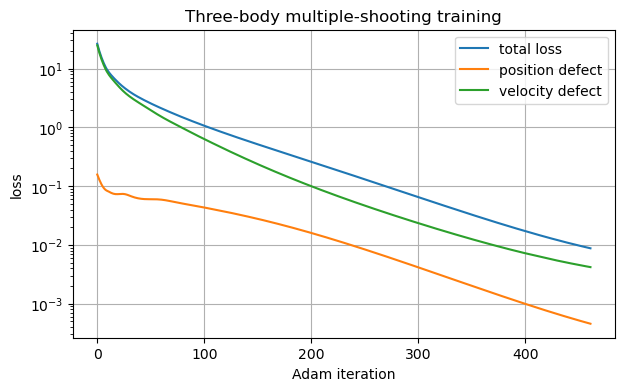

In [95]:
loss_values = [h["loss"] for h in history]
pos_values = [h["position_defect"] for h in history]
vel_values = [h["velocity_defect"] for h in history]

plt.figure(figsize=(7, 4))
plt.semilogy(loss_values, label="total loss")
plt.semilogy(pos_values, label="position defect")
plt.semilogy(vel_values, label="velocity defect")
plt.xlabel("Adam iteration")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.title("Three-body multiple-shooting training")
plt.show()

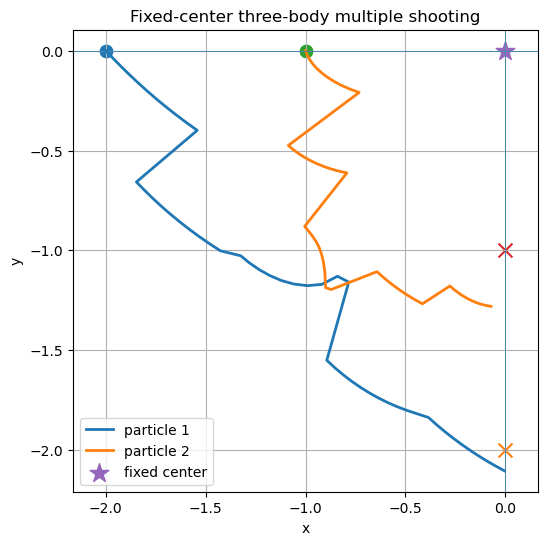

In [96]:
def plot_particle_trajectories(
    mu_traj,
    source_positions,
    target_positions,
    fixed_position,
    title="Fixed-center three-body multiple shooting",
):
    """
    mu_traj: Tensor[n_time, dim]
    """

    q = mu_traj.reshape(-1, n_moving, particle_dim).detach().cpu()
    source_np = source_positions.detach().cpu()
    target_np = target_positions.detach().cpu()
    fixed_np = fixed_position.detach().cpu()

    plt.figure(figsize=(6, 6))

    for i in range(n_moving):
        plt.plot(
            q[:, i, 0],
            q[:, i, 1],
            linewidth=2,
            label=f"particle {i+1}",
        )

        plt.scatter(
            source_np[i, 0],
            source_np[i, 1],
            marker="o",
            s=80,
        )

        plt.scatter(
            target_np[i, 0],
            target_np[i, 1],
            marker="x",
            s=100,
        )

    plt.scatter(
        fixed_np[0],
        fixed_np[1],
        marker="*",
        s=200,
        label="fixed center",
    )

    plt.axhline(0.0, linewidth=0.5)
    plt.axvline(0.0, linewidth=0.5)

    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()


plot_particle_trajectories(
    mu_ms,
    source_positions,
    target_positions,
    fixed_position,
)

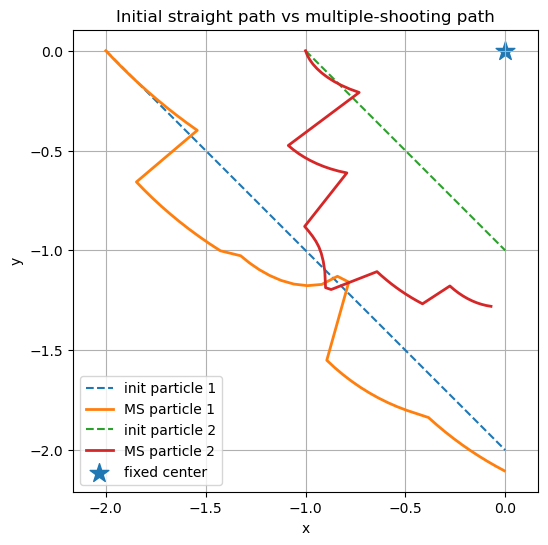

In [97]:
plt.figure(figsize=(6, 6))

q_init = mu_init_nodes.reshape(-1, n_moving, particle_dim).detach().cpu()
q_ms = mu_ms.reshape(-1, n_moving, particle_dim).detach().cpu()

for i in range(n_moving):
    plt.plot(
        q_init[:, i, 0],
        q_init[:, i, 1],
        "--",
        linewidth=1.5,
        label=f"init particle {i+1}",
    )

    plt.plot(
        q_ms[:, i, 0],
        q_ms[:, i, 1],
        linewidth=2.0,
        label=f"MS particle {i+1}",
    )

plt.scatter(
    fixed_position.detach().cpu()[0],
    fixed_position.detach().cpu()[1],
    marker="*",
    s=200,
    label="fixed center",
)

plt.axis("equal")
plt.grid(True)
plt.legend()
plt.title("Initial straight path vs multiple-shooting path")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

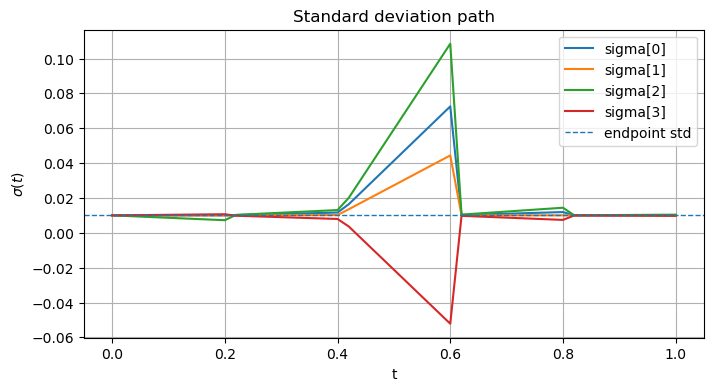

In [93]:
plt.figure(figsize=(8, 4))

for j in range(dim):
    plt.plot(
        t_ms.detach().cpu(),
        sigma_ms[:, j].detach().cpu(),
        label=f"sigma[{j}]",
    )

plt.axhline(endpoint_std, linestyle="--", linewidth=1.0, label="endpoint std")
plt.xlabel("t")
plt.ylabel(r"$\sigma(t)$")
plt.title("Standard deviation path")
plt.grid(True)
plt.legend()
plt.show()